# Lab 4: K-Means, Linear Regression and Logistic Regression

*Written by Sai Raj Kishore Perla, modified by Yalda.*

This notebook implements three basic machine learning algorithms from scratch with NumPy:

1. **K-means clustering** (unsupervised): group unlabeled points into clusters. This is a recap; you write the main functions yourself.
2. **Linear regression** (supervised): fit a line to data with gradient descent.
3. **Logistic regression** (supervised): separate two classes with gradient descent.

Each part follows the same pattern: **make toy data → run a few steps by hand → run the full loop.**
For each TODO, write your code, then run the check cell. The solutions are hidden; open them only after you've tried.

# **Unsupervised Learning**: K-Means Clustering

Import Libraries

In [22]:
# Import the libraries
import numpy as np
import matplotlib.pyplot as plt

Generate data

300 2-D points scattered around 3 random centers. There are **no labels** — K-means has to find the groups itself.

**TODO 1:** fill in `generate_data`.

In [23]:
# Function to generate a toy dataset with specified parameters
def generate_data(num_samples=300, num_features=2, num_clusters=3, cluster_std=1.0):
    np.random.seed(42)  # For reproducibility
    data = []
    for i in range(num_clusters):
        # TODO: randomly choose a center for this cluster, uniformly between -10 and 10
        #       (hint: np.random.uniform, one value per feature)
        center = ...
        # TODO: generate num_samples // num_clusters points around the center
        #       (hint: np.random.normal(center, cluster_std, size=(n, num_features)))
        points = ...
        data.append(points)
    return np.vstack(data)  # Combine all points into a single array

#### Solution

Try it yourself first, then open the hidden cell below.

In [46]:
#@title Solution

# Function to generate a toy dataset with specified parameters
def generate_data(num_samples=300, num_features=2, num_clusters=3, cluster_std=1.0):
    np.random.seed(42)  # For reproducibility
    data = []
    for i in range(num_clusters):
        # Randomly choose a center for each cluster
        center = np.random.uniform(-10, 10, num_features)
        # Generate points around the center with a normal distribution
        points = np.random.normal(center, cluster_std, size=(num_samples // num_clusters, num_features))
        data.append(points)
    return np.vstack(data)  # Combine all points into a single array

In [47]:
# run this cell to check your code
d = generate_data()
d0 = generate_data(num_samples=60, cluster_std=0.0)  # std 0 -> every point sits exactly on its center
print("correct:", d.shape == (300, 2) and d0.shape == (60, 2)
      and len(np.unique(d0, axis=0)) == 3 and np.all(np.abs(d0) <= 10))

correct: True


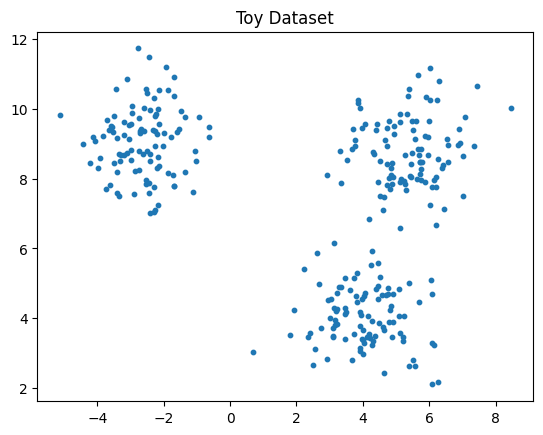

In [48]:
# Generate the toy dataset
data = generate_data()
# Plot the generated data
plt.scatter(data[:, 0:1], data[:, 1], s=10)
plt.title("Toy Dataset")
plt.show()

Utility function to visualize the results

In [49]:
# Function to plot the final clusters and centroids
def plot_clusters(data, clusters, centroids):
    # Plot data points colored by their cluster assignment
    plt.scatter(data[:, 0], data[:, 1], c=clusters, s=10, cmap='viridis')
    # Plot centroids as red 'X' markers
    plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X')
    plt.title("K-means Clustering")
    plt.show()

Define functions

K-means repeats two steps:
1. **Assign** — each point joins its nearest centroid.
2. **Update** — each centroid moves to the mean of its points.



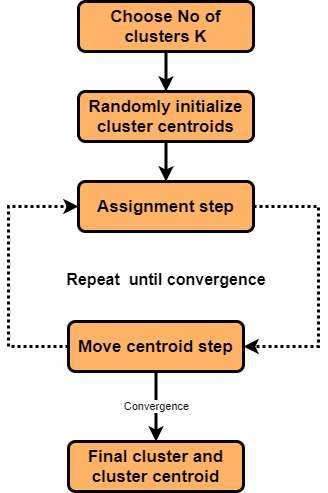

**TODO 2: Initialize.** Pick `k` random data points as the starting centroids.

In [32]:
# Function to randomly initialize centroids
def initialize_centroids(data, k):
    # TODO: pick k different random row indices of data (hint: np.random.choice with replace=False)
    indices = ...
    # TODO: return the data points at those indices
    return ...

#### Solution

Try it yourself first, then open the hidden cell below.

In [50]:
#@title Solution

# Function to randomly initialize centroids
def initialize_centroids(data, k):
    # Randomly select k unique indices from the data
    indices = np.random.choice(data.shape[0], k, replace=False)
    # indices = np.array([0, 1, 2])
    return data[indices]  # Return the data points at those indices

In [51]:
# run this cell to check your code
toy_data = np.array([[0, 0], [1, 0], [10, 10], [9, 10]])
c = initialize_centroids(toy_data, 3)
rows_from_data = all(any(np.array_equal(row, p) for p in toy_data) for row in c)
print("correct:", c.shape == (3, 2) and rows_from_data and len(np.unique(c, axis=0)) == 3)

correct: True


**TODO 3: Assign step.** For every point, find the index of its nearest centroid.

In [ ]:
# Function to assign each data point to the nearest centroid
def assign_clusters(data, centroids):
    # TODO: compute the distance between every point and every centroid
    # Hint: data[:, np.newaxis] has shape (N, 1, 2) and centroids has shape (k, 2),
    #       so their difference has shape (N, k, 2). Then use np.linalg.norm(..., axis=2)
    distances = ...
    # TODO: for each point, pick the index of the closest centroid (np.argmin)
    clusters = ...
    return clusters

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Function to assign each data point to the nearest centroid
def assign_clusters(data, centroids):
    # Calculate the distance between each data point and each centroid
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
    # Assign each point to the nearest centroid
    return np.argmin(distances, axis=1)

In [52]:
# run this cell to check your code
toy_data = np.array([[0, 0], [1, 0], [10, 10], [9, 10]])
toy_centroids = np.array([[0, 0], [10, 10]])
print("correct:", np.array_equal(assign_clusters(toy_data, toy_centroids), [0, 0, 1, 1]))

correct: True


**TODO 4: Update step.** Move each centroid to the mean of the points assigned to it.

In [ ]:
# Function to update centroids based on the mean of assigned points
def update_centroids(data, clusters, k):
    new_centroids = []
    for i in range(k):
        # TODO: get all points assigned to cluster i (hint: boolean mask clusters == i)
        cluster_points = ...
        # TODO: compute the mean of those points (hint: axis=0)
        centroid = ...
        new_centroids.append(centroid)
    return np.vstack(new_centroids)  # Combine new centroids into a single array

#### Solution

Try it yourself first, then open the hidden cell below.

In [53]:
#@title Solution

# Function to update centroids based on the mean of assigned points
def update_centroids(data, clusters, k):
    new_centroids = []
    for i in range(k):
        # Get all points assigned to the current cluster
        cluster_points = data[clusters == i]
        # Calculate the mean of those points to get the new centroid
        new_centroids.append(cluster_points.mean(axis=0))
    return np.vstack(new_centroids)  # Combine new centroids into a single array

In [54]:
# run this cell to check your code
toy_data = np.array([[0, 0], [1, 0], [10, 10], [9, 10]])
toy_clusters = np.array([0, 0, 1, 1])
print("correct:", np.allclose(update_centroids(toy_data, toy_clusters, 2), [[0.5, 0], [9.5, 10]]))

correct: True


Visualize K-Means progression

One cell = one assign + update step. Watch the red **X**s move toward the cluster centers.

**TODO 5:** start K-means: pick the first centroids and assign the points. The plot is your check.

In [ ]:
k = 3  # Number of clusters

# TODO: pick k starting centroids (use your function from TODO 2)
centroids = ...
# TODO: assign every point to its nearest centroid (use your function from TODO 3)
clusters = ...

plot_clusters(data, clusters, centroids)

#### Solution

Try it yourself first, then open the hidden cell below.

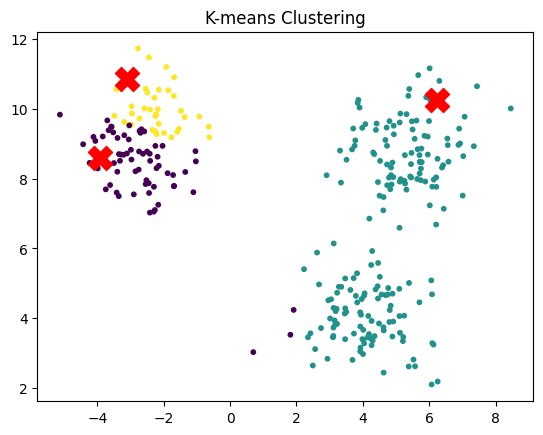

In [55]:
#@title Solution

k = 3  # Number of clusters

centroids = initialize_centroids(data, k)  # Initialize centroids
clusters = assign_clusters(data, centroids)  # Assign clusters to data points

plot_clusters(data, clusters, centroids)

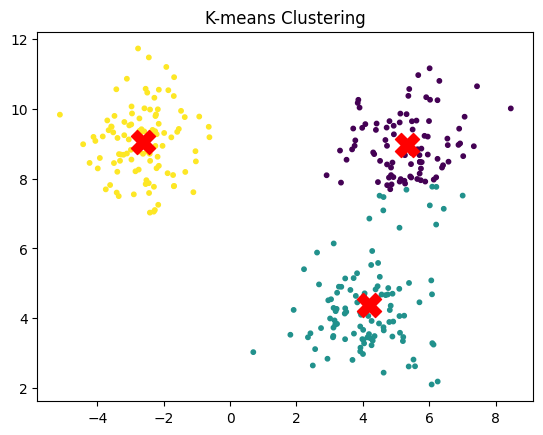

In [36]:
# ITERATION 1

clusters = assign_clusters(data, centroids)  # Assign clusters to data points
centroids = update_centroids(data, clusters, k)  # Update centroids

plot_clusters(data, clusters, centroids)

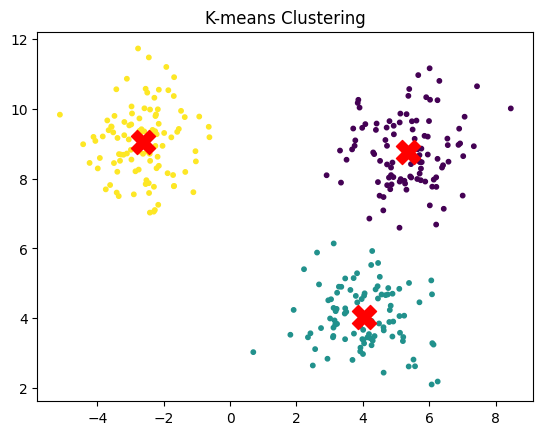

In [37]:
# ITERATION 2

clusters = assign_clusters(data, centroids)  # Assign clusters to data points
centroids = update_centroids(data, clusters, k)  # Update centroids

plot_clusters(data, clusters, centroids)

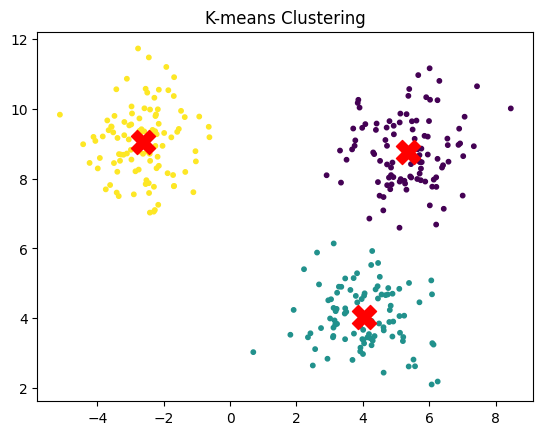

In [38]:
# ITERATION 3

clusters = assign_clusters(data, centroids)  # Assign clusters to data points
centroids = update_centroids(data, clusters, k)  # Update centroids

plot_clusters(data, clusters, centroids)

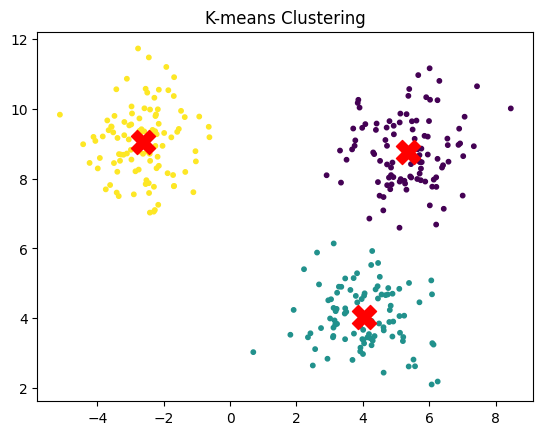

In [39]:
# ITERATION 4

clusters = assign_clusters(data, centroids)  # Assign clusters to data points
centroids = update_centroids(data, clusters, k)  # Update centroids

plot_clusters(data, clusters, centroids)

K-Means Clustering

Same steps in a loop. Stop when the centroids barely move (change < `tol`).

**TODO 6:** put your functions together in a loop.

In [ ]:
# Function to perform the K-means algorithm
def kmeans(data, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(data, k)  # Initialize centroids
    for _ in range(max_iters):
        # TODO: assign each point to a cluster (use your function from TODO 3)
        clusters = ...
        # TODO: compute the new centroids (use your function from TODO 4)
        new_centroids = ...
        # TODO: stop the loop if no centroid moved more than tol (hint: np.abs, np.all, break)
        ...
        centroids = new_centroids  # Update centroids for the next iteration
    return centroids, clusters

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Function to perform the K-means algorithm
def kmeans(data, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(data, k)  # Initialize centroids
    for _ in range(max_iters):
        clusters = assign_clusters(data, centroids)  # Assign clusters
        new_centroids = update_centroids(data, clusters, k)  # Update centroids
        # Check for convergence (if centroids do not change significantly)
        if np.all(np.abs(new_centroids - centroids) < tol):
            break
        centroids = new_centroids  # Update centroids for the next iteration
    return centroids, clusters

In [56]:
# run this cell to check your code
toy_data = np.array([[0, 0], [1, 0], [10, 10], [9, 10]])
toy_centroids, toy_clusters = kmeans(toy_data, 2)
toy_centroids = toy_centroids[np.argsort(toy_centroids[:, 0])]  # sort so the order doesn't matter
print("correct:", np.allclose(toy_centroids, [[0.5, 0], [9.5, 10]]))

correct: True


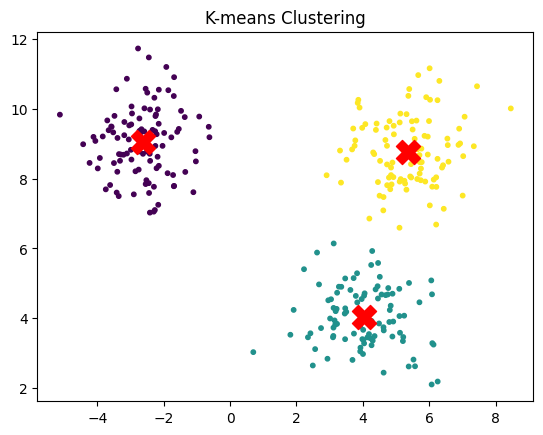

In [57]:
centroids, clusters = kmeans(data, k)  # Run K-means algorithm

plot_clusters(data, clusters, centroids)

# **Supervised Learning**: Linear Regression

Now every `x` comes with a target `y`. Goal: find the line $\hat{y} = w\,x + b$ that best fits the data.

Import Libraries

In [87]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

Generate and Visual data

The true line is $y = 2.5x$, plus random noise.

**TODO 7:** make the data.

In [ ]:
# Generate some random data
np.random.seed(0)  # For reproducibility

# TODO: 50 evenly spaced x values from 0 to 10 (hint: np.linspace)
x = ...
# TODO: y = 2.5 * x plus Gaussian noise with mean 0 and std 5 (hint: np.random.normal(0, 5, x.size))
y = ...

# Visualize the generated data
plt.scatter(x, y, label='Data points')
plt.title('Generated Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

#### Solution

Try it yourself first, then open the hidden cell below.

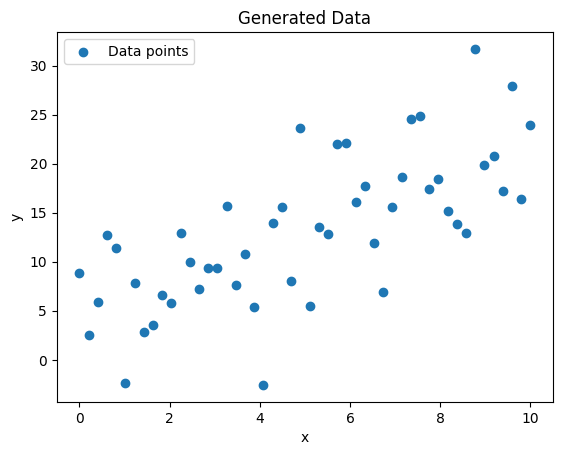

In [88]:
#@title Solution

# Generate some random data
np.random.seed(0)  # For reproducibility

x = np.linspace(0, 10, 50)
y = 2.5 * x + np.random.normal(0, 5, x.size)

# Visualize the generated data
plt.scatter(x, y, label='Data points')
plt.title('Generated Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [89]:
# run this cell to check your code
fit_slope = np.polyfit(x, y, 1)[0]  # slope of the best line through your data
print("correct:", x.shape == (50,) and y.shape == (50,) and x[0] == 0 and x[-1] == 10 and 1.5 < fit_slope < 3.5)

correct: True


Initialize Variables

Start from a random slope and intercept. `learning_rate` = step size.

**TODO 8:** pick a random starting slope and intercept.

In [ ]:
# TODO: initialize the slope and intercept with random numbers (hint: np.random.randn())
slope = ...
intercept = ...

# Learning rate and number of iterations for gradient descent
learning_rate = 0.01
num_iterations = 1000

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Initialize parameters for the line (slope and intercept)
slope = np.random.randn()
intercept = np.random.randn()

# Learning rate and number of iterations for gradient descent
learning_rate = 0.01
num_iterations = 1000

Gradient Descent

- **Loss (MSE):** $L = \text{mean}\big((y - \hat{y})^2\big)$ — how far the line is from the points.
- **Gradients:** $\partial L/\partial w = -2\,\text{mean}(x\,(y-\hat{y}))$, $\;\partial L/\partial b = -2\,\text{mean}(y-\hat{y})$
- **Update:** move a small step *against* the gradient: $w \leftarrow w - \alpha\,\partial L/\partial w$

After TODO 9, each ITERATION cell below runs one step. Watch the red line move toward the data.

**TODO 9: One gradient descent step.** Use the three formulas above (loss, gradients, update).

In [ ]:
# Function to take one gradient descent step for the line y = slope * x + intercept
def gradient_step(x, y, slope, intercept, learning_rate):
    # TODO: predictions of the current line
    y_pred = ...

    # TODO: error for each point (actual minus predicted) and the MSE loss
    error = ...
    mse = ...

    # TODO: gradients of the loss (see the formulas above)
    slope_gradient = ...
    intercept_gradient = ...

    # TODO: move a small step against the gradient
    slope = ...
    intercept = ...
    return slope, intercept, mse

#### Solution

Try it yourself first, then open the hidden cell below.

In [91]:
#@title Solution

# Function to take one gradient descent step for the line y = slope * x + intercept
def gradient_step(x, y, slope, intercept, learning_rate):
    # Calculate predictions
    y_pred = slope * x + intercept

    # Calculate the error (L2 loss)
    error = y - y_pred
    mse = np.mean(error**2)

    # Calculate gradients
    slope_gradient = -2 * np.mean(x * error)
    intercept_gradient = -2 * np.mean(error)

    # Update parameters
    slope = slope - learning_rate * slope_gradient
    intercept = intercept - learning_rate * intercept_gradient
    return slope, intercept, mse

In [ ]:
# run this cell to check your code
toy_x = np.array([0.0, 1.0, 2.0])
toy_y = np.array([1.0, 3.0, 5.0])
s, b, m = gradient_step(toy_x, toy_y, slope=0.0, intercept=0.0, learning_rate=0.1)
print("correct:", np.allclose([s, b, m], [0.8667, 0.6, 11.6667], atol=1e-3))

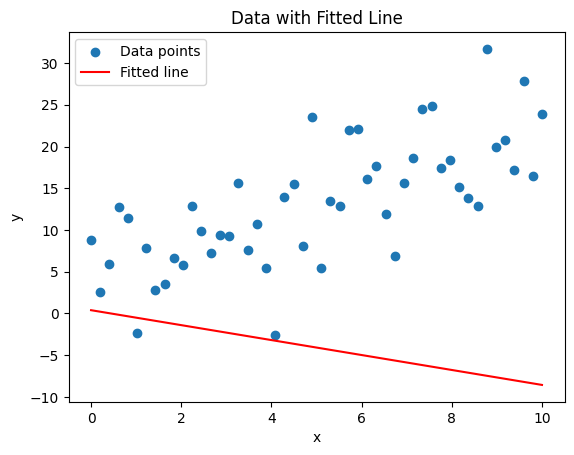

In [19]:
# INITIALIZATION

# Calculate the fitted line values
y_fit = slope * x + intercept

# Visualize the data and the fitted line
plt.scatter(x, y, label='Data points')
plt.plot(x, y_fit, color='red', label='Fitted line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

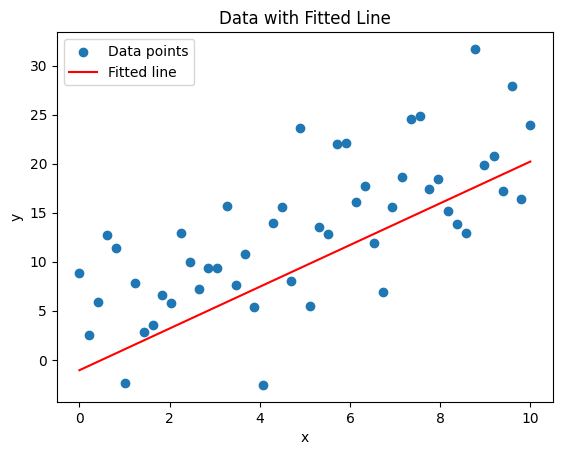

In [78]:
# ITERATION 1

# Take one gradient descent step (your function from TODO 9)
slope, intercept, mse = gradient_step(x, y, slope, intercept, learning_rate)

# Calculate the fitted line values
y_fit = slope * x + intercept

# Visualize the data and the fitted line
plt.scatter(x, y, label='Data points')
plt.plot(x, y_fit, color='red', label='Fitted line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

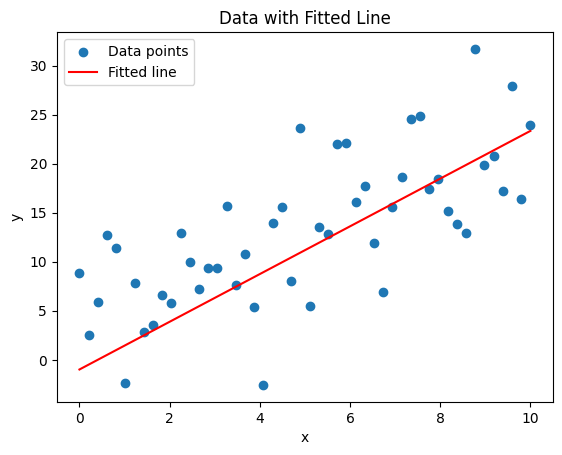

In [79]:
# ITERATION 2

# Take one gradient descent step (your function from TODO 9)
slope, intercept, mse = gradient_step(x, y, slope, intercept, learning_rate)

# Calculate the fitted line values
y_fit = slope * x + intercept

# Visualize the data and the fitted line
plt.scatter(x, y, label='Data points')
plt.plot(x, y_fit, color='red', label='Fitted line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

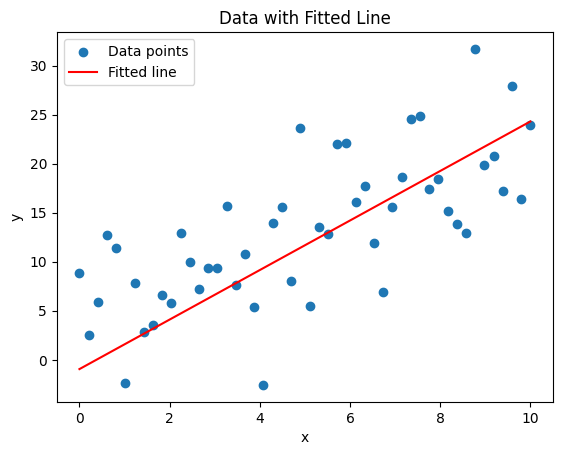

In [80]:
# ITERATION 3

# Take one gradient descent step (your function from TODO 9)
slope, intercept, mse = gradient_step(x, y, slope, intercept, learning_rate)

# Calculate the fitted line values
y_fit = slope * x + intercept

# Visualize the data and the fitted line
plt.scatter(x, y, label='Data points')
plt.plot(x, y_fit, color='red', label='Fitted line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**TODO 10: Full loop.** Put your `gradient_step` in a loop and run 1000 steps. The error should go down.

In [ ]:
np.random.seed(0)  # For reproducibility

# Initialize parameters for the line (slope and intercept)
slope = np.random.randn()
intercept = np.random.randn()

# Learning rate and number of iterations for gradient descent
learning_rate = 0.01
num_iterations = 1000

# Gradient descent algorithm
for i in range(num_iterations):
    # TODO: take one gradient descent step (use your function from TODO 9)
    slope, intercept, mse = ...

    # Print the progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: Slope = {slope}, Intercept = {intercept}, Error = {mse}")

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

np.random.seed(0)  # For reproducibility

# Initialize parameters for the line (slope and intercept)
slope = np.random.randn()
intercept = np.random.randn()

# Learning rate and number of iterations for gradient descent
learning_rate = 0.01
num_iterations = 1000

# Gradient descent algorithm
for i in range(num_iterations):
    # Take one gradient descent step
    slope, intercept, mse = gradient_step(x, y, slope, intercept, learning_rate)

    # Print the progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: Slope = {slope}, Intercept = {intercept}, Error = {mse}")

Iteration 0: Slope = 2.1675178324682824, Intercept = 0.4798047568344222, Error = 43.216395286722815
Iteration 100: Slope = 2.1303887895257287, Intercept = 1.9845912936677277, Error = 28.663418930187827
Iteration 200: Slope = 1.997040530582604, Intercept = 2.875930822782092, Error = 27.827635013876115
Iteration 300: Slope = 1.916582682876858, Intercept = 3.413735070516463, Error = 27.523367117792567
Iteration 400: Slope = 1.868037127736148, Intercept = 3.7382280380487307, Error = 27.41259811305309
Iteration 500: Slope = 1.8387463749864768, Intercept = 3.934016164344649, Error = 27.3722725559736
Iteration 600: Slope = 1.82107332141534, Intercept = 4.052148124768886, Error = 27.357592000184592
Iteration 700: Slope = 1.8104099961946594, Intercept = 4.123424970498447, Error = 27.352247530476475
Iteration 800: Slope = 1.803976104942969, Intercept = 4.166431018302196, Error = 27.35030187141073
Iteration 900: Slope = 1.800094111682715, Intercept = 4.192379418919081, Error = 27.349593552455467


In [ ]:
# run this cell to check your code
best_slope, best_intercept = np.polyfit(x, y, 1)  # exact least-squares line, for comparison
print("your line:  slope =", round(slope, 3), " intercept =", round(intercept, 3))
print("best line:  slope =", round(best_slope, 3), " intercept =", round(best_intercept, 3))
print("correct:", abs(slope - best_slope) < 0.2 and abs(intercept - best_intercept) < 1.0)

**TODO 11: Residuals.** A residual is *actual − predicted* for each point: how far the point is above (+) or below (−) the line.

If the line fits well, the residuals look like random noise around 0, with no pattern.

In [ ]:
# Calculate the fitted line values
y_fit = slope * x + intercept

# Visualize the data and the fitted line
plt.scatter(x, y, label='Data points')
plt.plot(x, y_fit, color='red', label='Fitted line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# TODO: compute the residuals (actual y minus the fitted line values)
residuals = ...

plt.scatter(x, residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals')
plt.xlabel('x')
plt.ylabel('Residual')
plt.legend()
plt.show()

#### Solution

Try it yourself first, then open the hidden cell below.

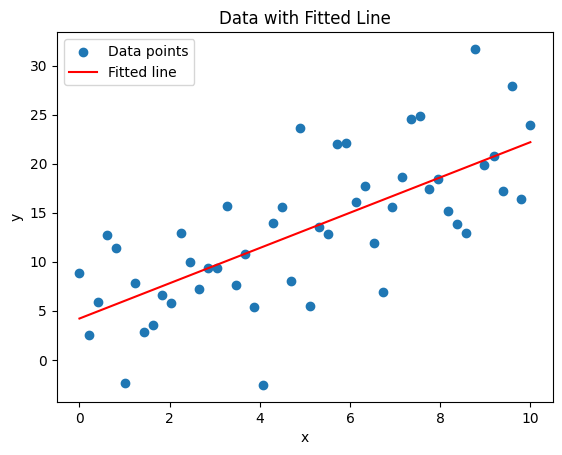

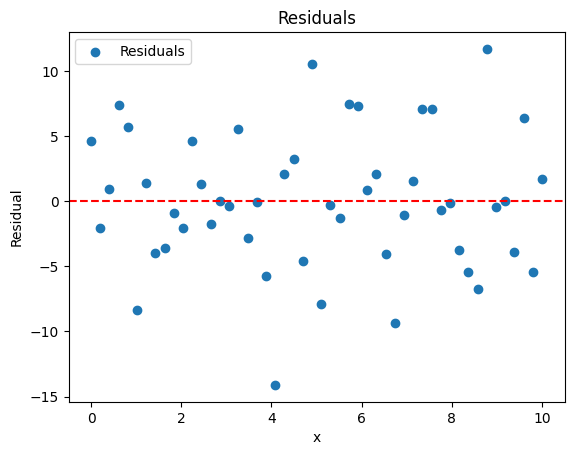

In [ ]:
#@title Solution

# Calculate the fitted line values
y_fit = slope * x + intercept

# Visualize the data and the fitted line
plt.scatter(x, y, label='Data points')
plt.plot(x, y_fit, color='red', label='Fitted line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Visualize residuals (differences between actual and fitted values)
residuals = y - y_fit
plt.scatter(x, residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals')
plt.xlabel('x')
plt.ylabel('Residual')
plt.legend()
plt.show()

# **Supervised Learning**: Logistic Regression

Now `y` is a class (0 or 1). Same gradient-descent recipe, but the linear output goes through a **sigmoid** to become a probability.

Import Libraries

In [92]:
import numpy as np
import matplotlib.pyplot as plt

Generate data and visualize

Two blobs of points: class 0 (blue) and class 1 (red).

**TODO 12:** make the two blobs and their labels.

In [ ]:
# Set random seed for reproducibility
np.random.seed(0)

# Generate 100 data points for two classes
n_samples = 100
# TODO: sample n_samples points around [2, 2] and n_samples around [7, 7]
#       with covariance [[1, 0.5], [0.5, 1]] (hint: np.random.multivariate_normal)
X1 = ...
X2 = ...

# TODO: stack the points into one array X (hint: np.vstack)
#       and make the labels y: 0 for X1, 1 for X2 (hint: np.zeros, np.ones, np.hstack)
X = ...
y = ...

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Toy Dataset')
plt.show()

#### Solution

Try it yourself first, then open the hidden cell below.

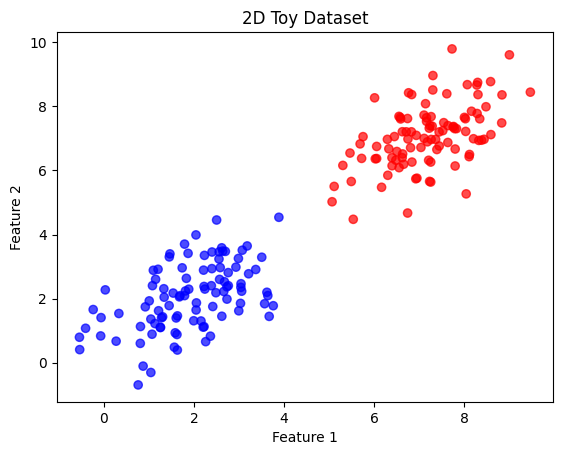

In [ ]:
#@title Solution

# Set random seed for reproducibility
np.random.seed(0)

# Generate 100 data points for two classes
n_samples = 100
X1 = np.random.multivariate_normal([2, 2], [[1, 0.5], [0.5, 1]], n_samples)
X2 = np.random.multivariate_normal([7, 7], [[1, 0.5], [0.5, 1]], n_samples)

# Combine the data
X = np.vstack((X1, X2))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Toy Dataset')
plt.show()

In [ ]:
# run this cell to check your code
print("correct:", X.shape == (200, 2) and y.shape == (200,)
      and np.all(y[:100] == 0) and np.all(y[100:] == 1)
      and np.allclose(X[:100].mean(axis=0), [2, 2], atol=0.5)
      and np.allclose(X[100:].mean(axis=0), [7, 7], atol=0.5))

Initialize Variables

**TODO 13:** start with weights and bias equal to 0.

In [ ]:
# TODO: start with all weights equal to 0 (one weight per feature) and bias 0 (hint: np.zeros)
theta = ...
bias = ...

# Learning rate and number of iterations
learning_rate = 0.1
n_iterations = 1000

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Initialize parameters
theta = np.zeros(X.shape[1])
bias = 0

# Learning rate and number of iterations
learning_rate = 0.1
n_iterations = 1000

Define helper functions

- `sigmoid` squashes any number into (0, 1) → a probability.
- `predict` says class 1 if the probability ≥ 0.5.

**TODO 14: Sigmoid.**

In [ ]:
# Sigmoid function
def sigmoid(z):
    # TODO: return 1 / (1 + e^(-z))  (hint: np.exp)
    return ...

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
# run this cell to check your code
print("correct:", np.allclose(sigmoid(np.array([-100.0, 0.0, 100.0])), [0.0, 0.5, 1.0]))

**TODO 15: Predict.** Turn the probability into a class.

In [ ]:
# Predict function
def predict(X, theta, bias):
    # TODO: predicted probability for each point (hint: np.dot(X, theta) + bias, then sigmoid)
    linear_model = ...
    y_predicted = ...
    # TODO: return True for class 1 (probability >= 0.5), False for class 0
    return ...

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Predict function
def predict(X, theta, bias):
    linear_model = np.dot(X, theta) + bias
    y_predicted = sigmoid(linear_model)
    return y_predicted >= 0.5

In [ ]:
# run this cell to check your code
toy_X = np.array([[1.0, 1.0], [-1.0, -1.0]])
print("correct:", np.array_equal(predict(toy_X, np.array([1.0, 1.0]), 0.0), [True, False]))

Gradient Descent

- **Prediction:** $p = \sigma(X\theta + b)$
- **Loss (cross-entropy):** $L = -\text{mean}\big(y\log p + (1-y)\log(1-p)\big)$
- **Gradients:** $dw = \text{mean}\big(X\,(p - y)\big)$, $\;db = \text{mean}(p - y)$

The shaded regions show the predicted class; the border between them is the **decision boundary**.

**TODO 16: One gradient descent step.** Use the formulas above (prediction, loss, gradients), then update like in linear regression.

In [ ]:
# Function to take one gradient descent step for logistic regression
def logistic_step(X, y, theta, bias, learning_rate):
    # TODO: predicted probability for each point (hint: np.dot(X, theta) + bias, then your sigmoid)
    linear_model = ...
    y_predicted = ...

    # TODO: cross-entropy loss (see the formula above, use np.log and np.mean)
    loss = ...

    # TODO: gradients (hint: dw uses np.dot(X.T, ...), both are divided by the number of points)
    dw = ...
    db = ...

    # TODO: move a small step against the gradient
    theta = ...
    bias = ...
    return theta, bias, loss

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Function to take one gradient descent step for logistic regression
def logistic_step(X, y, theta, bias, learning_rate):
    # Linear model
    linear_model = np.dot(X, theta) + bias
    y_predicted = sigmoid(linear_model)

    # Cross-entropy loss
    loss = -np.mean(y * np.log(y_predicted) + (1 - y) * np.log(1 - y_predicted))

    # Compute gradients
    dw = (1 / X.shape[0]) * np.dot(X.T, (y_predicted - y))
    db = (1 / X.shape[0]) * np.sum(y_predicted - y)

    # Update parameters
    theta = theta - learning_rate * dw
    bias = bias - learning_rate * db
    return theta, bias, loss

In [ ]:
# run this cell to check your code
toy_X = np.array([[1.0, 0.0], [0.0, 1.0]])
toy_y = np.array([0.0, 1.0])
t, b, l = logistic_step(toy_X, toy_y, theta=np.zeros(2), bias=0.0, learning_rate=1.0)
print("correct:", np.allclose(t, [-0.25, 0.25]) and np.isclose(b, 0.0) and np.isclose(l, np.log(2)))

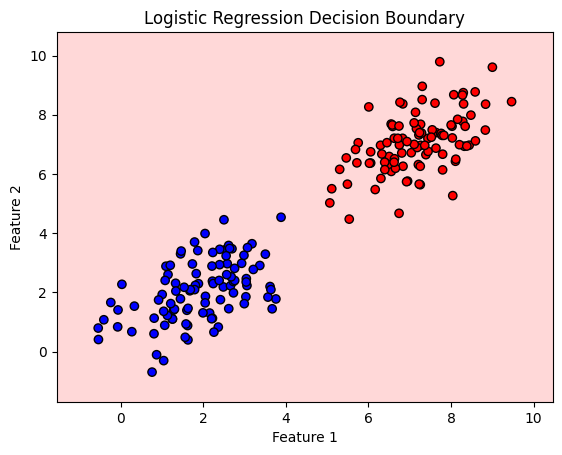

In [98]:
# INITIAL

# Generate a grid of points
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 100), np.linspace(x1_min, x1_max, 100))
grid = np.c_[xx0.ravel(), xx1.ravel()]

# Predict on the grid
probs = predict(grid, theta, bias).reshape(xx0.shape)

# Plot the decision boundary
plt.contourf(xx0, xx1, probs, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

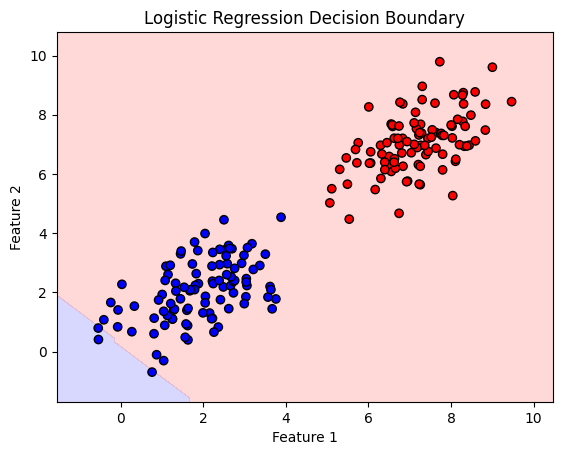

In [100]:
# ITERATION 1

# Take one gradient descent step (your function from TODO 16)
theta, bias, loss = logistic_step(X, y, theta, bias, learning_rate)


# Generate a grid of points
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 100), np.linspace(x1_min, x1_max, 100))
grid = np.c_[xx0.ravel(), xx1.ravel()]

# Predict on the grid
probs = predict(grid, theta, bias).reshape(xx0.shape)

# Plot the decision boundary
plt.contourf(xx0, xx1, probs, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

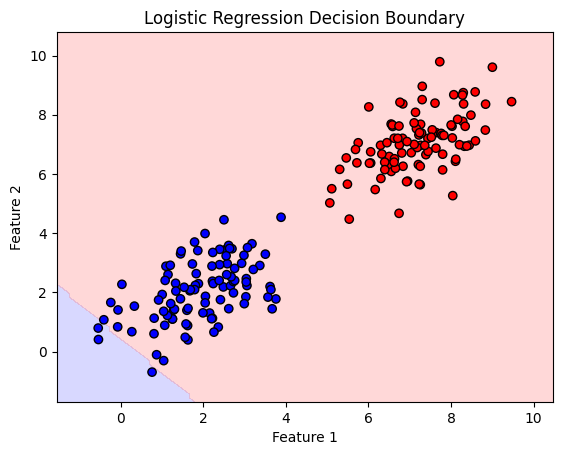

In [101]:
# ITERATION 2

# Take one gradient descent step (your function from TODO 16)
theta, bias, loss = logistic_step(X, y, theta, bias, learning_rate)


# Generate a grid of points
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 100), np.linspace(x1_min, x1_max, 100))
grid = np.c_[xx0.ravel(), xx1.ravel()]

# Predict on the grid
probs = predict(grid, theta, bias).reshape(xx0.shape)

# Plot the decision boundary
plt.contourf(xx0, xx1, probs, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

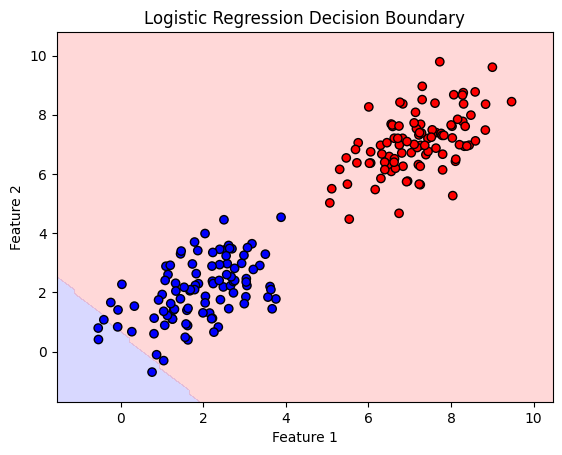

In [102]:
# ITERATION 3

# Take one gradient descent step (your function from TODO 16)
theta, bias, loss = logistic_step(X, y, theta, bias, learning_rate)


# Generate a grid of points
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 100), np.linspace(x1_min, x1_max, 100))
grid = np.c_[xx0.ravel(), xx1.ravel()]

# Predict on the grid
probs = predict(grid, theta, bias).reshape(xx0.shape)

# Plot the decision boundary
plt.contourf(xx0, xx1, probs, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

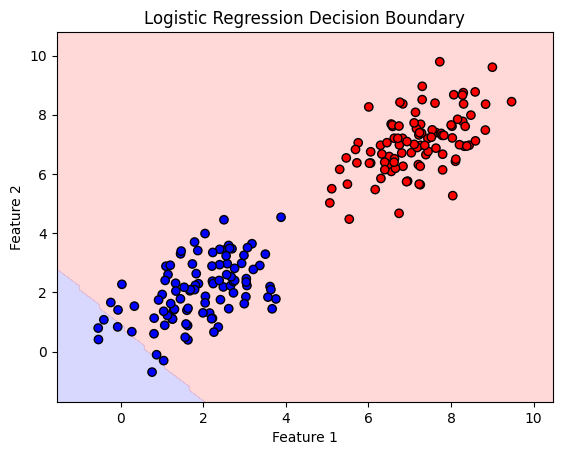

In [103]:
# ITERATION 4

# Take one gradient descent step (your function from TODO 16)
theta, bias, loss = logistic_step(X, y, theta, bias, learning_rate)


# Generate a grid of points
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 100), np.linspace(x1_min, x1_max, 100))
grid = np.c_[xx0.ravel(), xx1.ravel()]

# Predict on the grid
probs = predict(grid, theta, bias).reshape(xx0.shape)

# Plot the decision boundary
plt.contourf(xx0, xx1, probs, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()

**TODO 17: Full loop.** Put your `logistic_step` in a loop and run 1000 steps. The loss should go down, and the boundary should end up between the two blobs.

In [ ]:
# Initialize parameters
theta = np.zeros(X.shape[1])
bias = 0

# Gradient descent
for i in range(n_iterations):
    # TODO: take one gradient descent step (use your function from TODO 16)
    theta, bias, loss = ...

    # Print the progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss}")

#### Solution

Try it yourself first, then open the hidden cell below.

In [ ]:
#@title Solution

# Initialize parameters
theta = np.zeros(X.shape[1])
bias = 0

# Gradient descent
for i in range(n_iterations):
    # Take one gradient descent step
    theta, bias, loss = logistic_step(X, y, theta, bias, learning_rate)

    # Print the progress every 100 iterations
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss}")

Iteration 0: Loss = 0.6931471805599452
Iteration 100: Loss = 0.29833342864225487
Iteration 200: Loss = 0.19890207317566272
Iteration 300: Loss = 0.1500168235321866
Iteration 400: Loss = 0.12121412547037927
Iteration 500: Loss = 0.10224469051708002
Iteration 600: Loss = 0.08879207791808476
Iteration 700: Loss = 0.07873935337423112
Iteration 800: Loss = 0.07092991792157849
Iteration 900: Loss = 0.06467917199651756


In [ ]:
# run this cell to check your code
accuracy = np.mean(predict(X, theta, bias) == y)
print("accuracy:", accuracy)
print("correct:", accuracy > 0.95)

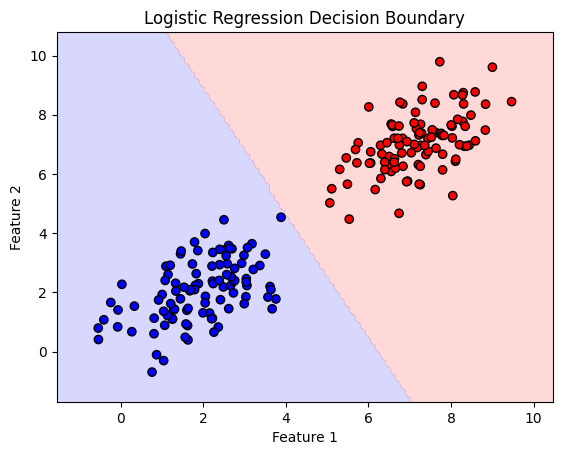

In [105]:
# Generate a grid of points
x0_min, x0_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_min, x1_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 100), np.linspace(x1_min, x1_max, 100))
grid = np.c_[xx0.ravel(), xx1.ravel()]

# Predict on the grid
probs = predict(grid, theta, bias).reshape(xx0.shape)

# Plot the decision boundary
plt.contourf(xx0, xx1, probs, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()